In [1]:
# importing libraries
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast 
import seaborn as sns 

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

def clean_list(lists):
    if pd.notna(lists):
        return ast.literal_eval(lists)
df['job_skills'] = df['job_skills'].apply(clean_list)

/opt/anaconda3/envs/python_da/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].dropna(subset='salary_year_avg')
df_DA_US_exp = df_DA_US.explode('job_skills')
df_DA_US_exp_grp = df_DA_US_exp.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by='count', ascending=False)
total_jobs = len(df_DA_US)
df_DA_US_exp_grp['skill_percent'] = df_DA_US_exp_grp['count']/total_jobs * 100
skill_percent = 5
df_DA_US_exp_grp_HD = df_DA_US_exp_grp[df_DA_US_exp_grp['skill_percent'] > skill_percent]
df_DA_US_exp_grp_HD


,median,count,skill_percent
job_skills,,,
sql,91000.00,2508,57.655172
excel,84392.00,1808,41.563218
python,97500.00,1431,32.896552
tableau,92875.00,1364,31.356322
sas,90000.00,926,21.287356
r,92500.00,893,20.528736
power bi,90000.00,838,19.264368
powerpoint,85000.00,462,10.620690
word,81194.75,461,10.597701


In [3]:
%pip install adjustText

Note: you may need to restart the kernel to use updated packages.


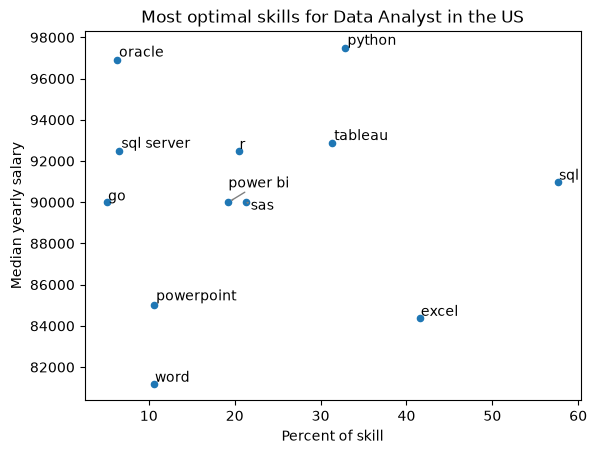

In [4]:
from adjustText import adjust_text

df_DA_US_exp_grp_HD.plot(kind='scatter',x='skill_percent',y='median')
    
# prepare texts for adjustText
texts = []

for i, txt in enumerate(df_DA_US_exp_grp_HD.index):
    text = plt.text(df_DA_US_exp_grp_HD['skill_percent'].iloc[i],df_DA_US_exp_grp_HD['median'].iloc[i],txt)
    texts.append(text)
 # adjust text to avoid overlap

adjust_text(texts,arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of skill')
plt.ylabel('Median yearly salary')
plt.title('Most optimal skills for Data Analyst in the US')

plt.show()

In [19]:
df_technology = df_DA_US['job_type_skills'].copy()
df_technology= df_technology.drop_duplicates()
df_technology= df_technology.dropna()



In [34]:
technology_dict = {}
# converting strings to dictionary
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

    for key, value in technology_dict.items():
        technology_dict[key] = list(set(value))

technology_dict.keys()

df_tech = pd.DataFrame(list(technology_dict.items()),columns=['technology', 'skills'])
df_tech_exp = df_tech.explode('skills')
df_tech_exp

,technology,skills
0,analyst_tools,spreadsheet
0,analyst_tools,excel
0,analyst_tools,sap
0,analyst_tools,sharepoint
0,analyst_tools,alteryx
...,...,...
9,sync,webex
9,sync,zoom
9,sync,symphony
9,sync,microsoft teams


In [39]:
df_real_plot = df_DA_US_exp_grp_HD.merge(df_tech_exp, left_on= 'job_skills', right_on= 'skills')

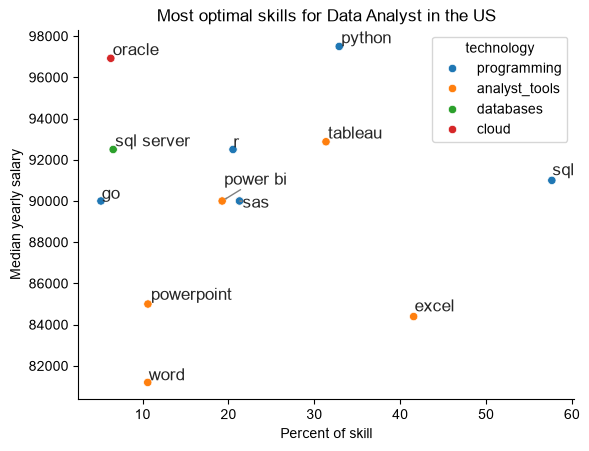

In [ ]:
from adjustText import adjust_text
sns.scatterplot(data= df_real_plot, x='skill_percent', y='median', hue='technology' )
sns.despine()
sns.set_theme(style='ticks')

    
# prepare texts for adjustText
texts = []

for i, txt in enumerate(df_DA_US_exp_grp_HD.index):
    text = plt.text(df_DA_US_exp_grp_HD['skill_percent'].iloc[i],df_DA_US_exp_grp_HD['median'].iloc[i],txt)
    texts.append(text)
 # adjust text to avoid overlap

adjust_text(texts,arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of skill')
plt.ylabel('Median yearly salary')
plt.title('Most optimal skills for Data Analyst in the US')

plt.show()